Small notebook for comparison of paleorca and orca runs

In [1]:
import xarray as xr
from cdo import Cdo
from glob import glob
import matplotlib.pyplot as plt
cdo = Cdo()

PATH = "/lus/h2resw01/scratch/ccpd/ece4"
# load NEMO output for a given experiment, with options to load only the last n years, regrid to a common grid, and handle running simulations
def load_nemo(expname, last_n_years=None, grid='T', regrid=False, running=False):
    nemofiles = sorted(glob(f"{PATH}/{expname}/output/nemo/{expname}_oce_1m_{grid}_*.nc"))
    print(f"Found {len(nemofiles)} files for experiment {expname}")
    if running:
        print("Simulation is running, removing the last file to avoid loading incomplete data.")
        nemofiles = nemofiles[:-1]
    if last_n_years is not None:
        if last_n_years >= len(nemofiles):
            raise ValueError(f"Requested last {last_n_years} years, but only {len(nemofiles)} files are available.")
        if last_n_years > 0:
            nemofiles = (nemofiles)[-last_n_years:]
    print(f"Loading following files: {nemofiles}")
    if regrid and last_n_years != 1:
        raise ValueError("Regridding is only supported for loading a single year of data.")
    if regrid:
        for f in nemofiles:
            print(f"Regridding {f}...")
            ds = cdo.remapnn("r360x180", input=f, returnXDataset=True)
    else:
        ds = xr.open_mfdataset(nemofiles, combine="by_coords", data_vars='all')
    ds = ds.rename({"time_counter": "time"})

    return ds

# compute area of each grid cell from the domain configuration file
def load_area(expname):
    areafile = f"{PATH}/{expname}/domain_cfg.nc"
    print(f"Loading area file: {areafile}")
    ds = xr.open_dataset(areafile)
    area = (ds['e1t'] * ds['e2t']).squeeze()
    return area

In [2]:
paleorca_last = load_nemo("KA02", last_n_years=1, regrid=True)
orca_last = load_nemo("KA03", last_n_years=1, regrid=True)


Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2039-2039.nc']
Regridding /lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2039-2039.nc...
Found 50 files for experiment KA03
Simulation is running, removing the last file to avoid loading incomplete data.
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA03/output/nemo/KA03_oce_1m_T_2038-2038.nc']
Regridding /lus/h2resw01/scratch/ccpd/ece4/KA03/output/nemo/KA03_oce_1m_T_2038-2038.nc...


Text(0.5, 1.0, 'Global mean weighted tos difference (KA02, PALEORCA - KA03, ORCA) for last year')

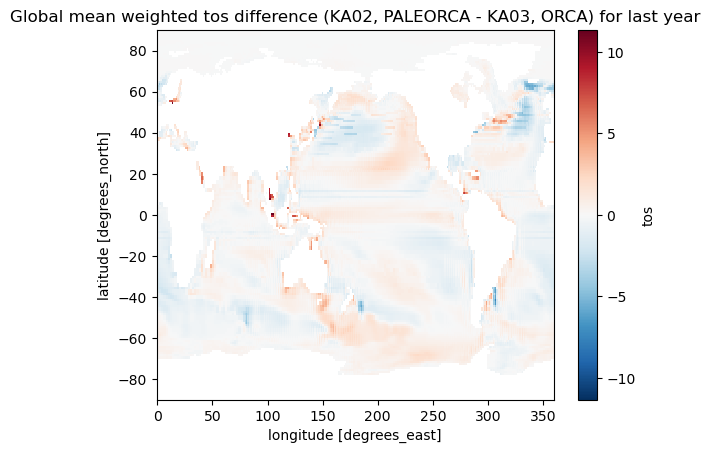

In [3]:
var = 'tos'
(paleorca_last[var].mean(dim='time') - orca_last[var].mean(dim='time')).plot()
plt.title(f"Global mean weighted {var} difference (KA02, PALEORCA - KA03, ORCA) for last year")

In [7]:
paleorca = load_nemo("KA02", last_n_years=None, regrid=False)
orca = load_nemo("KA03", last_n_years=None, regrid=False)

Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1990-1990.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1991-1991.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1992-1992.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1993-1993.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1994-1994.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1995-1995.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1996-1996.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1997-1997.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1998-1998.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1999-1999.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2000-2000.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2001-2

Loading area file: /lus/h2resw01/scratch/ccpd/ece4/KA02/domain_cfg.nc
Loading area file: /lus/h2resw01/scratch/ccpd/ece4/KA03/domain_cfg.nc


Text(0.5, 1.0, 'Global mean weighted tos difference (KA02, PALEORCA - KA03, ORCA)')

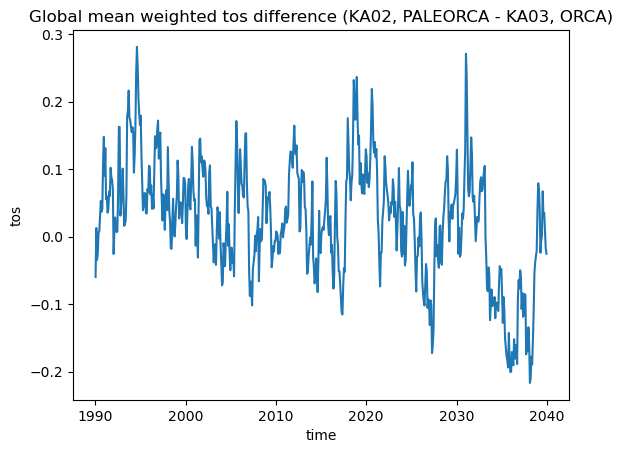

In [8]:
var = 'tos'
paleorca_area = load_area("KA02")
orca_area = load_area("KA03")
paleorca_ts = paleorca['tos'].weighted(paleorca_area).mean(dim=["y", "x"])
orca_ts = orca['tos'].weighted(orca_area).mean(dim=["y", "x"])
(paleorca_ts - orca_ts).plot()
plt.title(f"Global mean weighted {var} difference (KA02, PALEORCA - KA03, ORCA)")

In [6]:
paleorca = load_nemo("KA02", last_n_years=None, regrid=False)
orca = load_nemo("KA03", last_n_years=None, regrid=False, running=True)

Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1990-1990.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1991-1991.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1992-1992.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1993-1993.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1994-1994.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1995-1995.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1996-1996.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1997-1997.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1998-1998.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1999-1999.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2000-2000.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2001-2